
esm-piControl
Found 25 files
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-piControl/latest/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_185101-186012.nc
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-piControl/latest/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_209101-210012.nc

esm-up2p0
Found 23 files
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_185001-185912.nc
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_207001-207412.nc

esm-up2p0-swl2p0
Found 31 files
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0-swl2p0/v20251009/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gr_195101-195912.nc
/nird/datalake/NS2980K/users/yongyub/O2_linearl

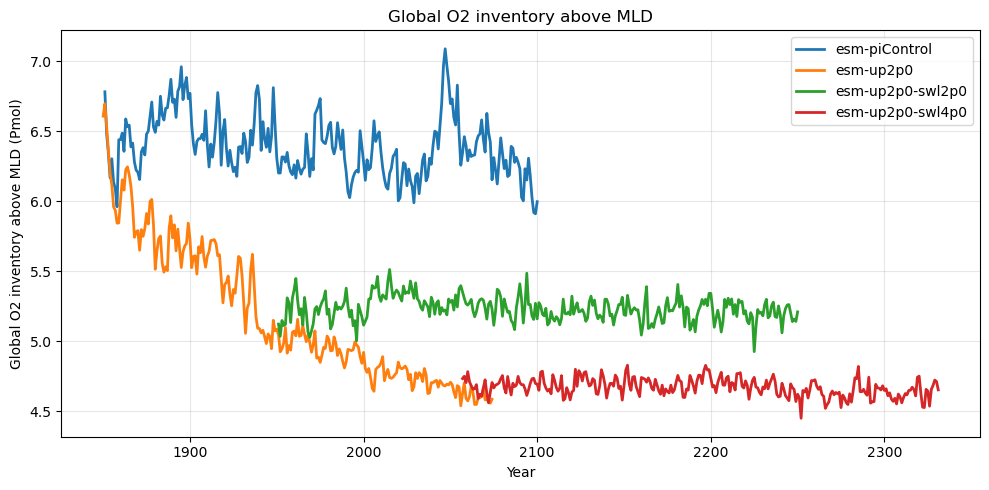

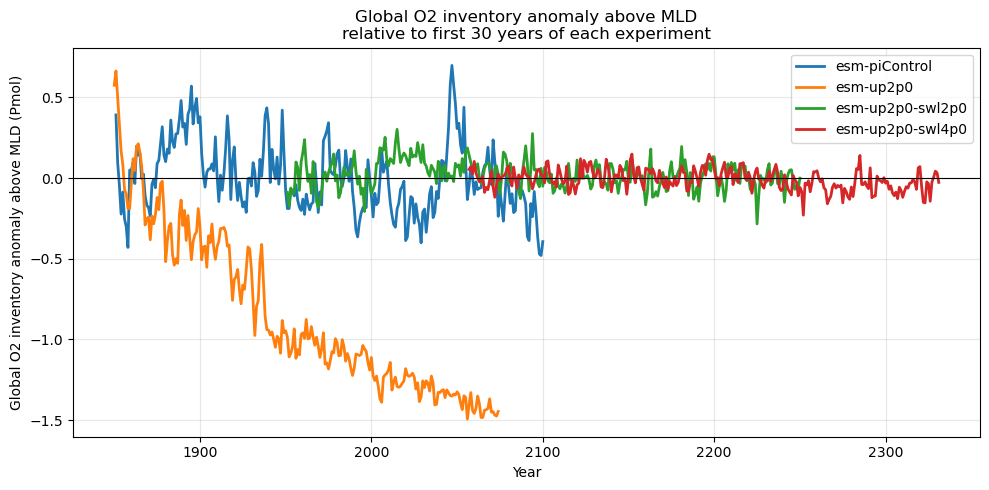

In [1]:
import xarray as xr
import numpy as np
import glob
import os
import matplotlib.pyplot as plt

# ============================================================
# Settings
# ============================================================

EXP_INFO = {
    "esm-piControl": {
        "path": "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-piControl/latest/o2-inventories",
        "pattern": "o2-inventories_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_*.nc",
    },
    "esm-up2p0": {
        "path": "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/o2-inventories",
        "pattern": "o2-inventories_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
    },
    "esm-up2p0-swl2p0": {
        "path": "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0-swl2p0/v20251009/o2-inventories",
        "pattern": "o2-inventories_Omon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gr_*.nc",
    },
    "esm-up2p0-swl4p0": {
        "path": "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0-swl4p0/v20251010/o2-inventories",
        "pattern": "o2-inventories_Omon_NorESM2-LM_esm-up2p0-swl4p0_r1i1p1f1_gr_*.nc",
    },
}

AREACELLO_FILE = (
    "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010/"
    "areacello_Ofx_NorESM2-LM_esm-up2p0_r1i1p1f1_gn.nc"
)

VAR_NAME = "o2_inv_mld"


# ============================================================
# Function
# ============================================================

def load_global_sum_o2_inventory(exp_path, pattern, var_name, areacello_file):
    files = sorted(glob.glob(os.path.join(exp_path, pattern)))

    if len(files) == 0:
        raise FileNotFoundError(f"No files found: {os.path.join(exp_path, pattern)}")

    print(f"Found {len(files)} files")
    print(files[0])
    print(files[-1])

    ds = xr.open_mfdataset(
        files,
        combine="by_coords",
        use_cftime=True,
        parallel=False,
    )

    ds_area = xr.open_dataset(areacello_file)
    area = ds_area["areacello"]

    o2_inv = ds[var_name]  # mol m-2

    # mol m-2 * m2 = mol
    o2_global = (o2_inv * area).sum(dim=["j", "i"], skipna=True)

    o2_global.name = f"{var_name}_global_sum"
    o2_global.attrs["units"] = "mol"

    o2_ann = o2_global.groupby("time.year").mean("time")
    o2_ann.name = f"{var_name}_global_sum_annual"

    ds.close()
    ds_area.close()

    return o2_ann


# ============================================================
# Load all experiments
# ============================================================

o2_ann_dict = {}

for exp, info in EXP_INFO.items():
    print("\n======================================")
    print(exp)
    print("======================================")

    o2_ann_dict[exp] = load_global_sum_o2_inventory(
        exp_path=info["path"],
        pattern=info["pattern"],
        var_name=VAR_NAME,
        areacello_file=AREACELLO_FILE,
    )


# ============================================================
# Plot absolute global O2 inventory
# ============================================================

plt.figure(figsize=(10, 5))

for exp, o2_ann in o2_ann_dict.items():
    plt.plot(
        o2_ann["year"],
        o2_ann / 1e15,   # mol -> Pmol
        lw=2,
        label=exp,
    )

plt.xlabel("Year")
plt.ylabel("Global O2 inventory above MLD (Pmol)")
plt.title("Global O2 inventory above MLD")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# Plot anomalies relative to each experiment's first 30 years
# ============================================================

plt.figure(figsize=(10, 5))

for exp, o2_ann in o2_ann_dict.items():
    years = o2_ann["year"].values
    ref_years = years[:30]

    o2_ref = o2_ann.sel(year=ref_years).mean("year")
    o2_anom = o2_ann - o2_ref

    plt.plot(
        o2_ann["year"],
        o2_anom / 1e15,   # mol -> Pmol
        lw=2,
        label=exp,
    )

plt.axhline(0, color="k", lw=0.8)
plt.xlabel("Year")
plt.ylabel("Global O2 inventory anomaly above MLD (Pmol)")
plt.title("Global O2 inventory anomaly above MLD\nrelative to first 30 years of each experiment")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


esm-piControl
Found 25 files
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-piControl/latest/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_185101-186012.nc
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-piControl/latest/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_209101-210012.nc

esm-up2p0
Found 23 files
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_185001-185912.nc
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_207001-207412.nc

esm-up2p0-swl2p0
Found 31 files
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0-swl2p0/v20251009/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gr_195101-195912.nc
/nird/datalake/NS2980K/users/yongyub/O2_linearl

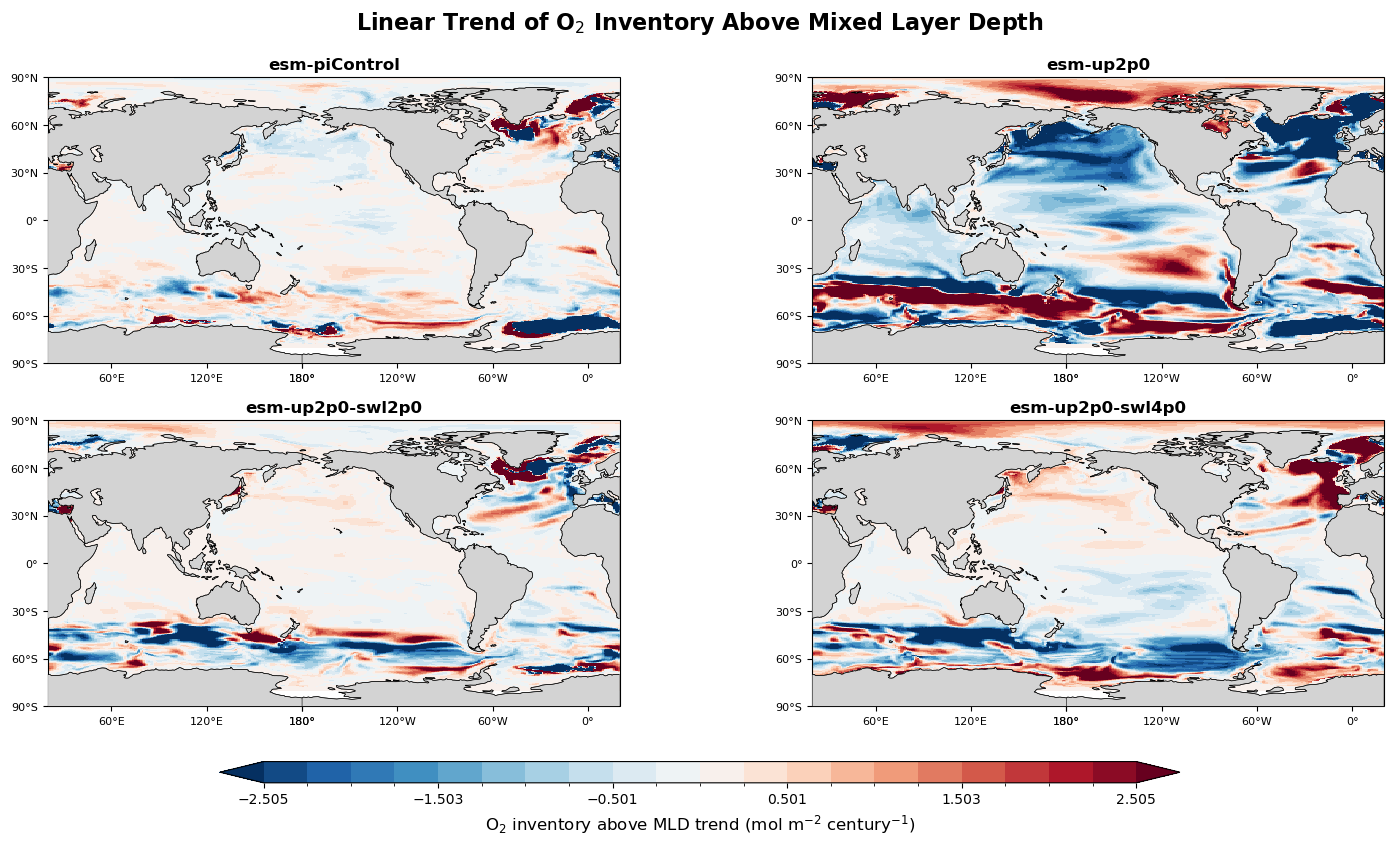

In [5]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import glob
import os
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

# ============================================================
# Settings
# ============================================================

EXP_INFO = {
    "esm-piControl": {
        "path": "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-piControl/latest/o2-inventories",
        "pattern": "o2-inventories_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_*.nc",
    },
    "esm-up2p0": {
        "path": "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/o2-inventories",
        "pattern": "o2-inventories_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
    },
    "esm-up2p0-swl2p0": {
        "path": "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0-swl2p0/v20251009/o2-inventories",
        "pattern": "o2-inventories_Omon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gr_*.nc",
    },
    "esm-up2p0-swl4p0": {
        "path": "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0-swl4p0/v20251010/o2-inventories",
        "pattern": "o2-inventories_Omon_NorESM2-LM_esm-up2p0-swl4p0_r1i1p1f1_gr_*.nc",
    },
}

VAR_NAME = "o2_inv_mld"


# ============================================================
# Function
# ============================================================

def compute_o2_inventory_trend_map(exp_path, pattern, var_name):
    files = sorted(glob.glob(os.path.join(exp_path, pattern)))

    if len(files) == 0:
        raise FileNotFoundError(f"No files found: {os.path.join(exp_path, pattern)}")

    print(f"Found {len(files)} files")
    print(files[0])
    print(files[-1])

    ds = xr.open_mfdataset(
        files,
        combine="by_coords",
        use_cftime=True,
        data_vars="minimal",
        coords="minimal",
        compat="override",
        chunks={"time": 120},
    )

    inv = ds[var_name]

    inv_ann = inv.groupby("time.year").mean("time")

    year = inv_ann["year"]
    x = year - year.mean()

    trend = (
        (inv_ann * x).sum("year", skipna=True)
        / (x ** 2).sum("year", skipna=True)
    ) * 100.0

    trend.name = f"{var_name}_trend"
    trend.attrs["units"] = "mol m-2 century-1"

    trend = trend.assign_coords(
        longitude=ds["longitude"],
        latitude=ds["latitude"],
    )

    trend = trend.compute()

    ds.close()

    return trend


# ============================================================
# Compute trend maps
# ============================================================

trend_dict = {}

for exp, info in EXP_INFO.items():
    print("\n======================================")
    print(exp)
    print("======================================")

    trend_dict[exp] = compute_o2_inventory_trend_map(
        exp_path=info["path"],
        pattern=info["pattern"],
        var_name=VAR_NAME,
    )


# ============================================================
# Plot 2 x 2 panel
# ============================================================

data_crs = ccrs.PlateCarree()
map_crs = ccrs.PlateCarree(central_longitude=200)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 8.5),
    subplot_kw={"projection": map_crs},
)

axes = axes.flatten()

# ------------------------------------------------------------
# common color range: based only on esm-up2p0
# cover about 90% of esm-up2p0 trend magnitudes
# ------------------------------------------------------------

ref_trend = trend_dict["esm-up2p0"]

ref_values = ref_trend.values
ref_values = ref_values[np.isfinite(ref_values)]

vmax = np.nanpercentile(np.abs(ref_values), 90)
vmin = -vmax

levels = np.linspace(vmin, vmax, 21)

cmap = plt.get_cmap("RdBu_r", len(levels) + 1).copy()
cmap.set_bad(alpha=0)

norm = mcolors.BoundaryNorm(
    levels,
    cmap.N,
    extend="both"
)

# ------------------------------------------------------------
# draw maps
# ------------------------------------------------------------

for ax, (exp, trend) in zip(axes, trend_dict.items()):

    pcm = ax.pcolormesh(
        trend["longitude"],
        trend["latitude"],
        trend,
        transform=data_crs,
        cmap=cmap,
        norm=norm,
        shading="auto",
    )

    ax.add_feature(
        cfeature.LAND,
        facecolor="lightgray",
        edgecolor="black",
        linewidth=0.3,
        zorder=10,
    )

    ax.coastlines(
        resolution="110m",
        linewidth=0.5,
        zorder=11,
    )

    ax.set_global()

    ax.set_xticks(np.arange(-180, 181, 60), crs=data_crs)
    ax.set_yticks(np.arange(-90, 91, 30), crs=data_crs)

    ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
    ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())

    ax.tick_params(labelsize=8)

    ax.set_title(
        exp,
        fontsize=12,
        fontweight="bold",
    )

# ------------------------------------------------------------
# layout first, then add colorbar outside
# ------------------------------------------------------------

fig.subplots_adjust(
    left=0.05,
    right=0.97,
    top=0.90,
    bottom=0.16,
    wspace=0.08,
    hspace=0.20,
)

cbar_ax = fig.add_axes([0.20, 0.07, 0.60, 0.025])

cbar = fig.colorbar(
    pcm,
    cax=cbar_ax,
    orientation="horizontal",
    boundaries=levels,
    ticks=levels[::4],
    spacing="proportional",
    extend="both",
)

cbar.set_label(
    "O$_2$ inventory above MLD trend (mol m$^{-2}$ century$^{-1}$)",
    fontsize=12,
)

fig.suptitle(
    "Linear Trend of O$_2$ Inventory Above Mixed Layer Depth",
    fontsize=16,
    fontweight="bold",
)

plt.show()


esm-piControl
Found 25 files
First: /nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-piControl/latest/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_185101-186012.nc
Last : /nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-piControl/latest/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_209101-210012.nc

esm-up2p0
Found 23 files
First: /nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_185001-185912.nc
Last : /nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_207001-207412.nc

esm-up2p0-swl2p0
Found 31 files
First: /nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0-swl2p0/v20251009/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gr_195101-195912.nc
Last : /nird

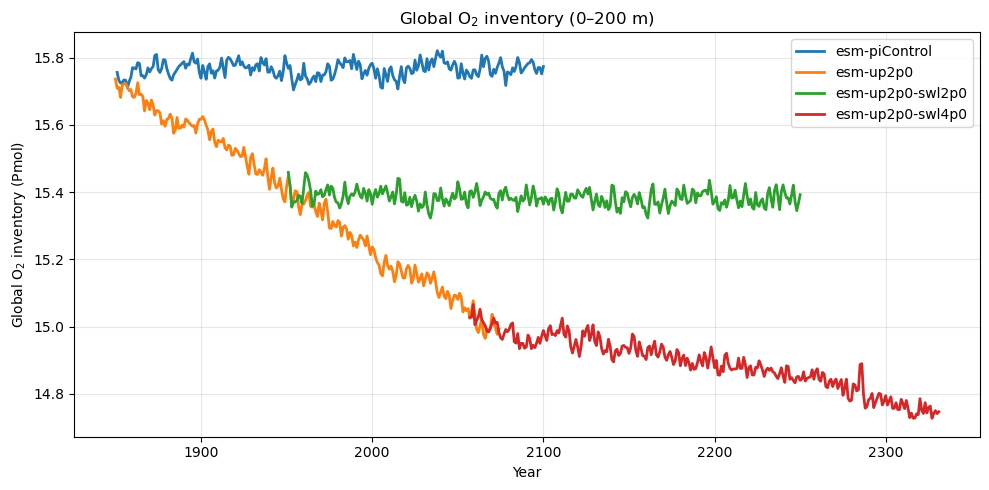

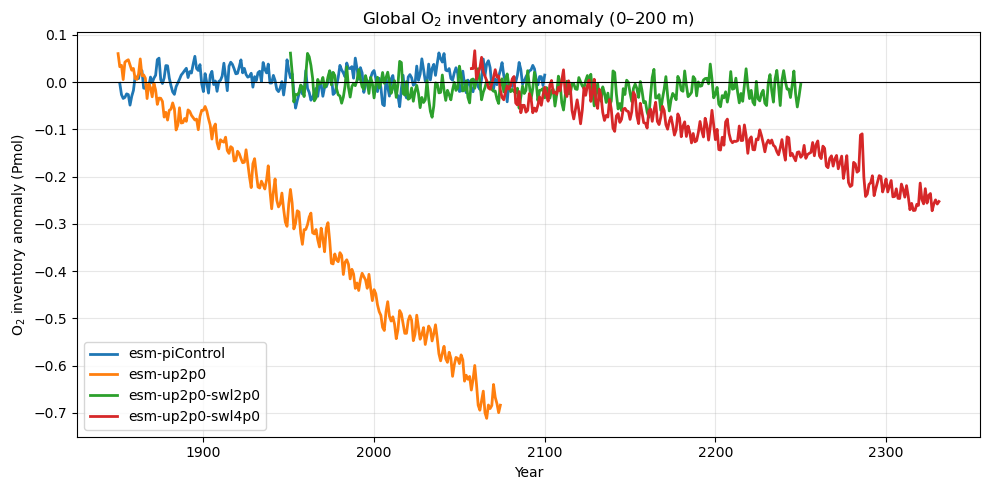

In [11]:
EXP_INFO = {
    "esm-piControl": {
        "path": "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-piControl/latest/o2-inventories",
        "pattern": "o2-inventories_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_*.nc",
    },
    "esm-up2p0": {
        "path": "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/o2-inventories",
        "pattern": "o2-inventories_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
    },
    "esm-up2p0-swl2p0": {
        "path": "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0-swl2p0/v20251009/o2-inventories",
        "pattern": "o2-inventories_Omon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gr_*.nc",
    },
    "esm-up2p0-swl4p0": {
        "path": "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0-swl4p0/v20251010/o2-inventories",
        "pattern": "o2-inventories_Omon_NorESM2-LM_esm-up2p0-swl4p0_r1i1p1f1_gr_*.nc",
    },
}


VAR_NAME = "o2_inv_200m"

# ============================================================
# Load all experiments
# ============================================================

o2_ann_dict = {}

for exp, info in EXP_INFO.items():
    print("\n======================================")
    print(exp)
    print("======================================")

    o2_ann_dict[exp] = load_global_sum_o2_inventory(
        exp_path=info["path"],
        pattern=info["pattern"],
        var_name=VAR_NAME,
        areacello_file=AREACELLO_FILE,
    )


plt.figure(figsize=(10, 5))

for exp, o2_ann in o2_ann_dict.items():
    plt.plot(
        o2_ann["year"],
        o2_ann / 1e15,
        lw=2,
        label=exp,
    )

plt.xlabel("Year")
plt.ylabel("Global O$_2$ inventory (Pmol)")
plt.title("Global O$_2$ inventory (0–200 m)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))

for exp, o2_ann in o2_ann_dict.items():

    ref_years = o2_ann["year"].values[:30]

    o2_ref = o2_ann.sel(year=ref_years).mean("year")
    o2_anom = o2_ann - o2_ref

    plt.plot(
        o2_ann["year"],
        o2_anom / 1e15,
        lw=2,
        label=exp,
    )

plt.axhline(0, color="k", lw=0.8)
plt.xlabel("Year")
plt.ylabel("O$_2$ inventory anomaly (Pmol)")
plt.title("Global O$_2$ inventory anomaly (0–200 m)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


esm-piControl
Found 25 files
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-piControl/latest/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_185101-186012.nc
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-piControl/latest/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_209101-210012.nc

esm-up2p0
Found 23 files
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_185001-185912.nc
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_207001-207412.nc

esm-up2p0-swl2p0
Found 31 files
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0-swl2p0/v20251009/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gr_195101-195912.nc
/nird/datalake/NS2980K/users/yongyub/O2_linearl

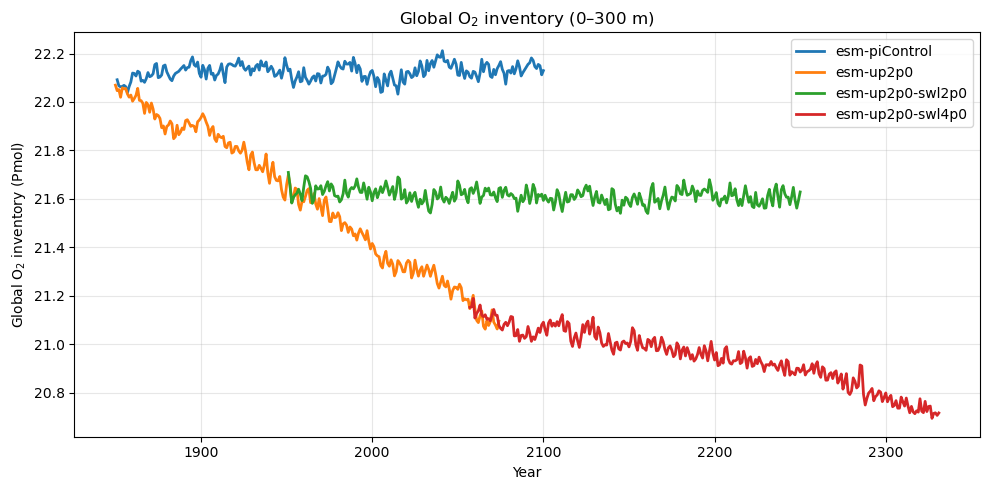

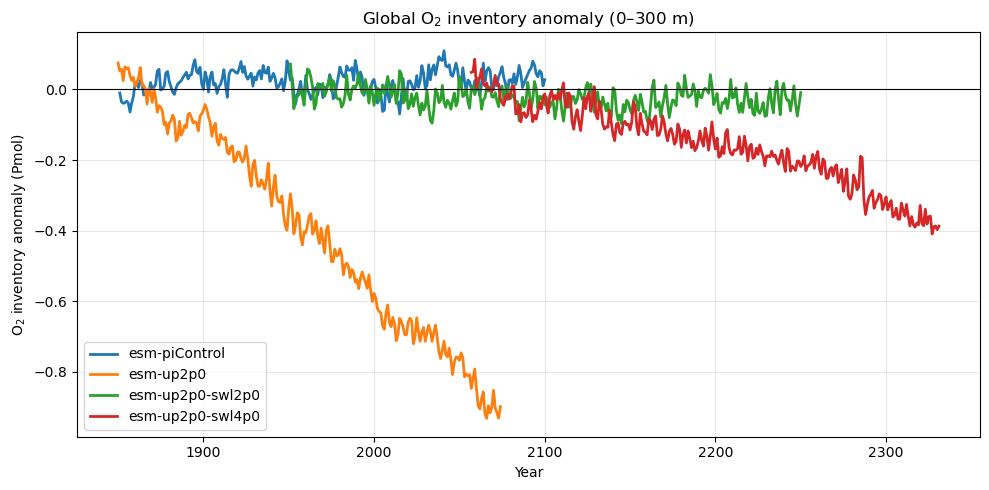

In [7]:
VAR_NAME = "o2_inv_300m"

# ============================================================
# Load all experiments
# ============================================================

o2_ann_dict = {}

for exp, info in EXP_INFO.items():
    print("\n======================================")
    print(exp)
    print("======================================")

    o2_ann_dict[exp] = load_global_sum_o2_inventory(
        exp_path=info["path"],
        pattern=info["pattern"],
        var_name=VAR_NAME,
        areacello_file=AREACELLO_FILE,
    )


plt.figure(figsize=(10, 5))

for exp, o2_ann in o2_ann_dict.items():
    plt.plot(
        o2_ann["year"],
        o2_ann / 1e15,
        lw=2,
        label=exp,
    )

plt.xlabel("Year")
plt.ylabel("Global O$_2$ inventory (Pmol)")
plt.title("Global O$_2$ inventory (0–300 m)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))

for exp, o2_ann in o2_ann_dict.items():

    ref_years = o2_ann["year"].values[:30]

    o2_ref = o2_ann.sel(year=ref_years).mean("year")
    o2_anom = o2_ann - o2_ref

    plt.plot(
        o2_ann["year"],
        o2_anom / 1e15,
        lw=2,
        label=exp,
    )

plt.axhline(0, color="k", lw=0.8)
plt.xlabel("Year")
plt.ylabel("O$_2$ inventory anomaly (Pmol)")
plt.title("Global O$_2$ inventory anomaly (0–300 m)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


esm-piControl
Found 25 files
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-piControl/latest/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_185101-186012.nc
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-piControl/latest/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_209101-210012.nc

esm-up2p0
Found 23 files
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_185001-185912.nc
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_207001-207412.nc

esm-up2p0-swl2p0
Found 31 files
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0-swl2p0/v20251009/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gr_195101-195912.nc
/nird/datalake/NS2980K/users/yongyub/O2_linearl

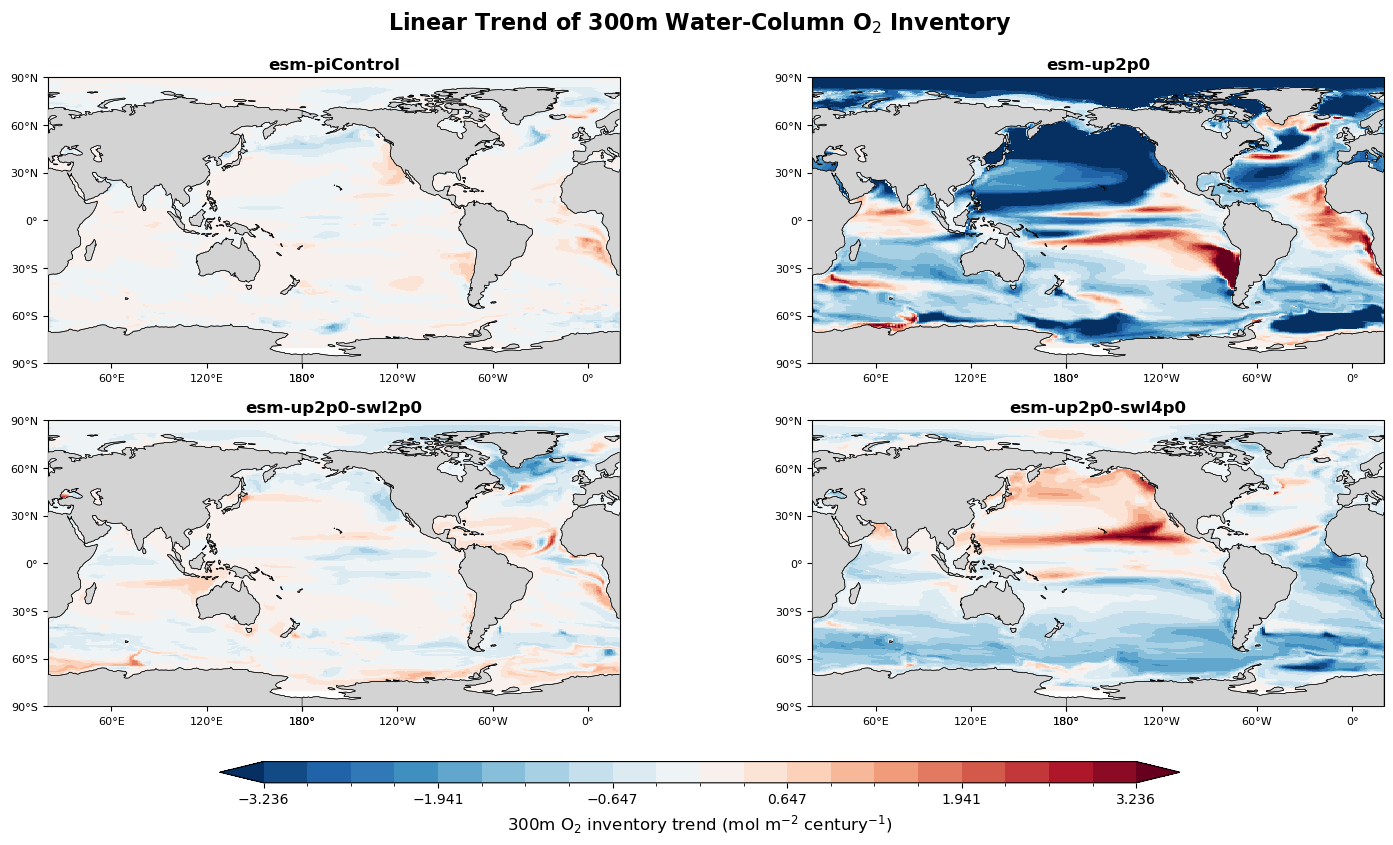

In [8]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import glob
import os
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

# ============================================================
# Settings
# ============================================================

EXP_INFO = {
    "esm-piControl": {
        "path": "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-piControl/latest/o2-inventories",
        "pattern": "o2-inventories_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_*.nc",
    },
    "esm-up2p0": {
        "path": "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/o2-inventories",
        "pattern": "o2-inventories_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
    },
    "esm-up2p0-swl2p0": {
        "path": "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0-swl2p0/v20251009/o2-inventories",
        "pattern": "o2-inventories_Omon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gr_*.nc",
    },
    "esm-up2p0-swl4p0": {
        "path": "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0-swl4p0/v20251010/o2-inventories",
        "pattern": "o2-inventories_Omon_NorESM2-LM_esm-up2p0-swl4p0_r1i1p1f1_gr_*.nc",
    },
}

VAR_NAME = "o2_inv_300m"


# ============================================================
# Function
# ============================================================

def compute_o2_inventory_trend_map(exp_path, pattern, var_name):
    files = sorted(glob.glob(os.path.join(exp_path, pattern)))

    if len(files) == 0:
        raise FileNotFoundError(f"No files found: {os.path.join(exp_path, pattern)}")

    print(f"Found {len(files)} files")
    print(files[0])
    print(files[-1])

    ds = xr.open_mfdataset(
        files,
        combine="by_coords",
        use_cftime=True,
        data_vars="minimal",
        coords="minimal",
        compat="override",
        chunks={"time": 120},
    )

    inv = ds[var_name]

    inv_ann = inv.groupby("time.year").mean("time")

    year = inv_ann["year"]
    x = year - year.mean()

    trend = (
        (inv_ann * x).sum("year", skipna=True)
        / (x ** 2).sum("year", skipna=True)
    ) * 100.0

    trend.name = f"{var_name}_trend"
    trend.attrs["units"] = "mol m-2 century-1"

    trend = trend.assign_coords(
        longitude=ds["longitude"],
        latitude=ds["latitude"],
    )

    trend = trend.compute()

    ds.close()

    return trend


# ============================================================
# Compute trend maps
# ============================================================

trend_dict = {}

for exp, info in EXP_INFO.items():
    print("\n======================================")
    print(exp)
    print("======================================")

    trend_dict[exp] = compute_o2_inventory_trend_map(
        exp_path=info["path"],
        pattern=info["pattern"],
        var_name=VAR_NAME,
    )


# ============================================================
# Plot 2 x 2 panel
# ============================================================

data_crs = ccrs.PlateCarree()
map_crs = ccrs.PlateCarree(central_longitude=200)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 8.5),
    subplot_kw={"projection": map_crs},
)

axes = axes.flatten()

# ------------------------------------------------------------
# common color range: based only on esm-up2p0
# cover about 90% of esm-up2p0 trend magnitudes
# ------------------------------------------------------------

ref_trend = trend_dict["esm-up2p0"]

ref_values = ref_trend.values
ref_values = ref_values[np.isfinite(ref_values)]

vmax = np.nanpercentile(np.abs(ref_values), 90)
vmin = -vmax

levels = np.linspace(vmin, vmax, 21)

cmap = plt.get_cmap("RdBu_r", len(levels) + 1).copy()
cmap.set_bad(alpha=0)

norm = mcolors.BoundaryNorm(
    levels,
    cmap.N,
    extend="both"
)

# ------------------------------------------------------------
# draw maps
# ------------------------------------------------------------

for ax, (exp, trend) in zip(axes, trend_dict.items()):

    pcm = ax.pcolormesh(
        trend["longitude"],
        trend["latitude"],
        trend,
        transform=data_crs,
        cmap=cmap,
        norm=norm,
        shading="auto",
    )

    ax.add_feature(
        cfeature.LAND,
        facecolor="lightgray",
        edgecolor="black",
        linewidth=0.3,
        zorder=10,
    )

    ax.coastlines(
        resolution="110m",
        linewidth=0.5,
        zorder=11,
    )

    ax.set_global()

    ax.set_xticks(np.arange(-180, 181, 60), crs=data_crs)
    ax.set_yticks(np.arange(-90, 91, 30), crs=data_crs)

    ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
    ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())

    ax.tick_params(labelsize=8)

    ax.set_title(
        exp,
        fontsize=12,
        fontweight="bold",
    )

# ------------------------------------------------------------
# layout first, then add colorbar outside
# ------------------------------------------------------------

fig.subplots_adjust(
    left=0.05,
    right=0.97,
    top=0.90,
    bottom=0.16,
    wspace=0.08,
    hspace=0.20,
)

cbar_ax = fig.add_axes([0.20, 0.07, 0.60, 0.025])

cbar = fig.colorbar(
    pcm,
    cax=cbar_ax,
    orientation="horizontal",
    boundaries=levels,
    ticks=levels[::4],
    spacing="proportional",
    extend="both",
)

cbar.set_label(
    "300m O$_2$ inventory trend (mol m$^{-2}$ century$^{-1}$)",
    fontsize=12,
)

fig.suptitle(
    "Linear Trend of 300m Water-Column O$_2$ Inventory",
    fontsize=16,
    fontweight="bold",
)

plt.show()


esm-piControl
Found 25 files
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-piControl/latest/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_185101-186012.nc
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-piControl/latest/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_209101-210012.nc

esm-up2p0
Found 23 files
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_185001-185912.nc
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_207001-207412.nc

esm-up2p0-swl2p0
Found 31 files
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0-swl2p0/v20251009/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gr_195101-195912.nc
/nird/datalake/NS2980K/users/yongyub/O2_linearl

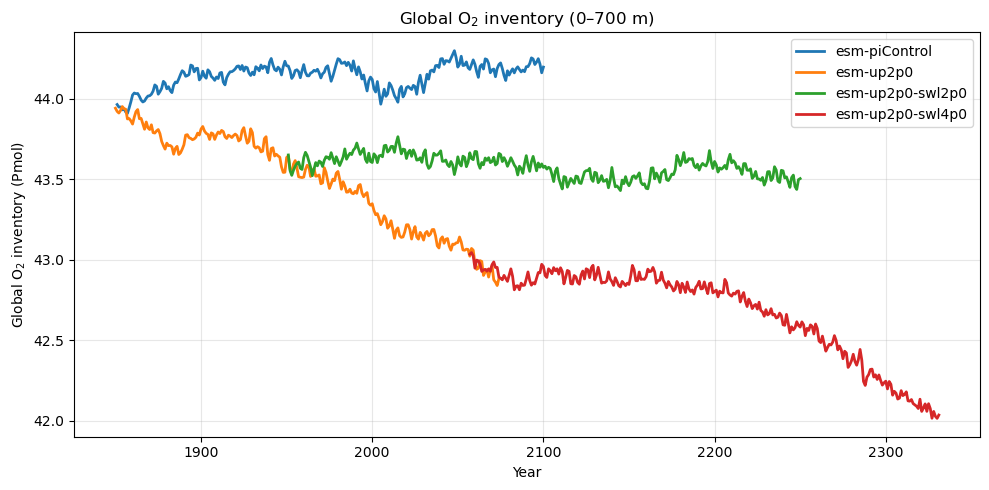

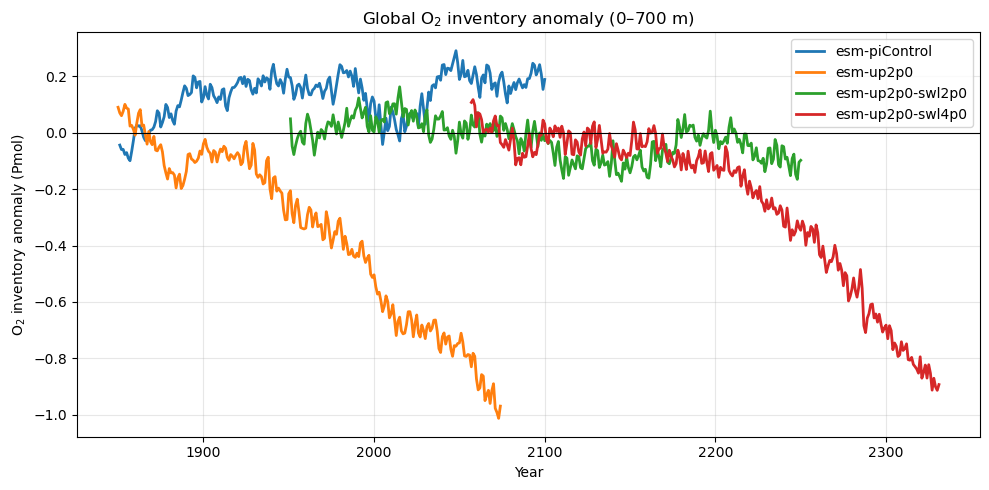

In [3]:
VAR_NAME = "o2_inv_700m"

# ============================================================
# Load all experiments
# ============================================================

o2_ann_dict = {}

for exp, info in EXP_INFO.items():
    print("\n======================================")
    print(exp)
    print("======================================")

    o2_ann_dict[exp] = load_global_sum_o2_inventory(
        exp_path=info["path"],
        pattern=info["pattern"],
        var_name=VAR_NAME,
        areacello_file=AREACELLO_FILE,
    )


plt.figure(figsize=(10, 5))

for exp, o2_ann in o2_ann_dict.items():
    plt.plot(
        o2_ann["year"],
        o2_ann / 1e15,
        lw=2,
        label=exp,
    )

plt.xlabel("Year")
plt.ylabel("Global O$_2$ inventory (Pmol)")
plt.title("Global O$_2$ inventory (0–700 m)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))

for exp, o2_ann in o2_ann_dict.items():

    ref_years = o2_ann["year"].values[:30]

    o2_ref = o2_ann.sel(year=ref_years).mean("year")
    o2_anom = o2_ann - o2_ref

    plt.plot(
        o2_ann["year"],
        o2_anom / 1e15,
        lw=2,
        label=exp,
    )

plt.axhline(0, color="k", lw=0.8)
plt.xlabel("Year")
plt.ylabel("O$_2$ inventory anomaly (Pmol)")
plt.title("Global O$_2$ inventory anomaly (0–700 m)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


esm-piControl
Found 25 files
First: /nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-piControl/latest/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_185101-186012.nc
Last : /nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-piControl/latest/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_209101-210012.nc
  [1/25] o2-inventories_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_185101-186012.nc
  [2/25] o2-inventories_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_186101-187012.nc
  [3/25] o2-inventories_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_187101-188012.nc
  [4/25] o2-inventories_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_188101-189012.nc
  [5/25] o2-inventories_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_189101-190012.nc
  [6/25] o2-inventories_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_190101-191012.nc
  [7/25] o2-inventories_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_191101-192012.nc
  [8/25] o2-inventories_Omon_

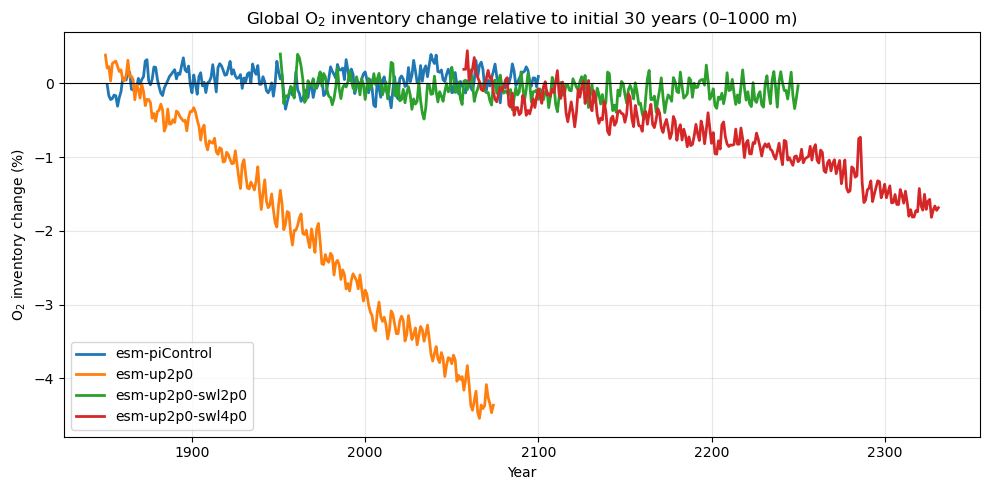

In [13]:
VAR_NAME = "o2_inv_200m"

# ============================================================
# Load all experiments
# ============================================================

o2_ann_dict = {}

for exp, info in EXP_INFO.items():
    print("\n======================================")
    print(exp)
    print("======================================")

    o2_ann_dict[exp] = load_global_sum_o2_inventory_fast(
        exp_path=info["path"],
        pattern=info["pattern"],
        var_name=VAR_NAME,
        areacello_file=AREACELLO_FILE,
    )


# ============================================================
# Plot: percent change relative to first 30 years
# ============================================================

plt.figure(figsize=(10, 5))

for exp, o2_ann in o2_ann_dict.items():

    # Reference = first 30 years
    o2_ref = o2_ann.isel(year=slice(0, 30)).mean("year")

    # Percent change relative to reference
    o2_pct = (o2_ann - o2_ref) / o2_ref * 100.0

    plt.plot(
        o2_ann["year"],
        o2_pct,
        lw=2,
        label=exp,
    )

plt.axhline(0, color="k", lw=0.8)
plt.xlabel("Year")
plt.ylabel("O$_2$ inventory change (%)")
plt.title("Global O$_2$ inventory change relative to initial 30 years (0–1000 m)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


esm-piControl
Found 25 files
First: /nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-piControl/latest/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_185101-186012.nc
Last : /nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-piControl/latest/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_209101-210012.nc
  [1/25] o2-inventories_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_185101-186012.nc
  [2/25] o2-inventories_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_186101-187012.nc
  [3/25] o2-inventories_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_187101-188012.nc
  [4/25] o2-inventories_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_188101-189012.nc
  [5/25] o2-inventories_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_189101-190012.nc
  [6/25] o2-inventories_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_190101-191012.nc
  [7/25] o2-inventories_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_191101-192012.nc
  [8/25] o2-inventories_Omon_

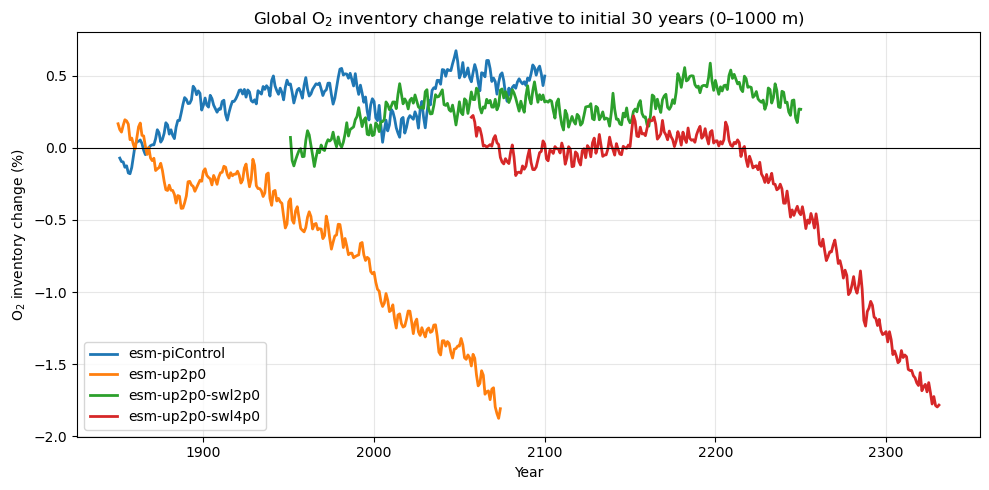

In [12]:
VAR_NAME = "o2_inv_1000m"

# ============================================================
# Load all experiments
# ============================================================

o2_ann_dict = {}

for exp, info in EXP_INFO.items():
    print("\n======================================")
    print(exp)
    print("======================================")

    o2_ann_dict[exp] = load_global_sum_o2_inventory_fast(
        exp_path=info["path"],
        pattern=info["pattern"],
        var_name=VAR_NAME,
        areacello_file=AREACELLO_FILE,
    )


# ============================================================
# Plot: percent change relative to first 30 years
# ============================================================

plt.figure(figsize=(10, 5))

for exp, o2_ann in o2_ann_dict.items():

    # Reference = first 30 years
    o2_ref = o2_ann.isel(year=slice(0, 30)).mean("year")

    # Percent change relative to reference
    o2_pct = (o2_ann - o2_ref) / o2_ref * 100.0

    plt.plot(
        o2_ann["year"],
        o2_pct,
        lw=2,
        label=exp,
    )

plt.axhline(0, color="k", lw=0.8)
plt.xlabel("Year")
plt.ylabel("O$_2$ inventory change (%)")
plt.title("Global O$_2$ inventory change relative to initial 30 years (0–1000 m)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


esm-piControl
Found 25 files
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-piControl/latest/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_185101-186012.nc
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-piControl/latest/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_209101-210012.nc

esm-up2p0
Found 23 files
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_185001-185912.nc
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_207001-207412.nc

esm-up2p0-swl2p0
Found 31 files
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0-swl2p0/v20251009/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gr_195101-195912.nc
/nird/datalake/NS2980K/users/yongyub/O2_linearl

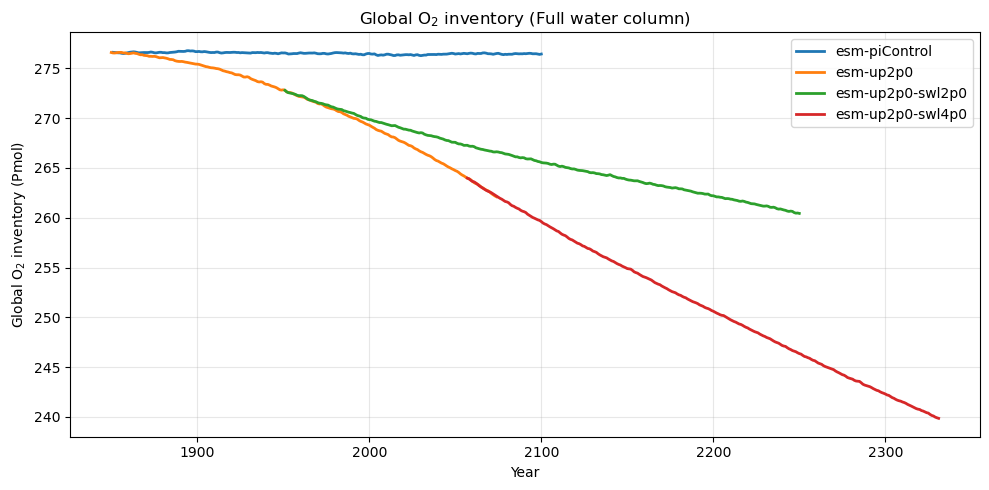

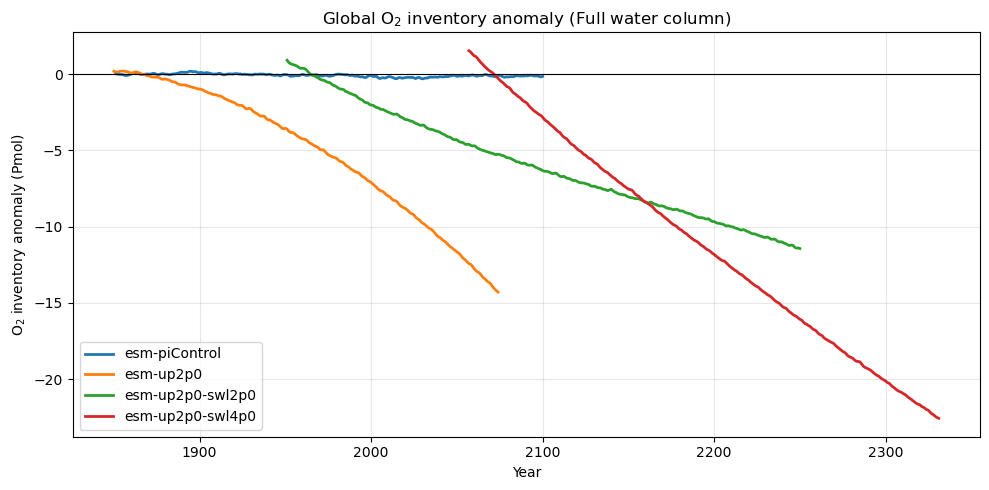

In [4]:
VAR_NAME = "o2_inv_total"

# ============================================================
# Load all experiments
# ============================================================

o2_ann_dict = {}

for exp, info in EXP_INFO.items():
    print("\n======================================")
    print(exp)
    print("======================================")

    o2_ann_dict[exp] = load_global_sum_o2_inventory(
        exp_path=info["path"],
        pattern=info["pattern"],
        var_name=VAR_NAME,
        areacello_file=AREACELLO_FILE,
    )


plt.figure(figsize=(10, 5))

for exp, o2_ann in o2_ann_dict.items():
    plt.plot(
        o2_ann["year"],
        o2_ann / 1e15,
        lw=2,
        label=exp,
    )

plt.xlabel("Year")
plt.ylabel("Global O$_2$ inventory (Pmol)")
plt.title("Global O$_2$ inventory (Full water column)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))

for exp, o2_ann in o2_ann_dict.items():

    ref_years = o2_ann["year"].values[:30]

    o2_ref = o2_ann.sel(year=ref_years).mean("year")
    o2_anom = o2_ann - o2_ref

    plt.plot(
        o2_ann["year"],
        o2_anom / 1e15,
        lw=2,
        label=exp,
    )

plt.axhline(0, color="k", lw=0.8)
plt.xlabel("Year")
plt.ylabel("O$_2$ inventory anomaly (Pmol)")
plt.title("Global O$_2$ inventory anomaly (Full water column)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


esm-piControl
Found 25 files
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-piControl/latest/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_185101-186012.nc
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-piControl/latest/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_209101-210012.nc

esm-up2p0
Found 23 files
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_185001-185912.nc
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_207001-207412.nc

esm-up2p0-swl2p0
Found 31 files
/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0-swl2p0/v20251009/o2-inventories/o2-inventories_Omon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gr_195101-195912.nc
/nird/datalake/NS2980K/users/yongyub/O2_linearl

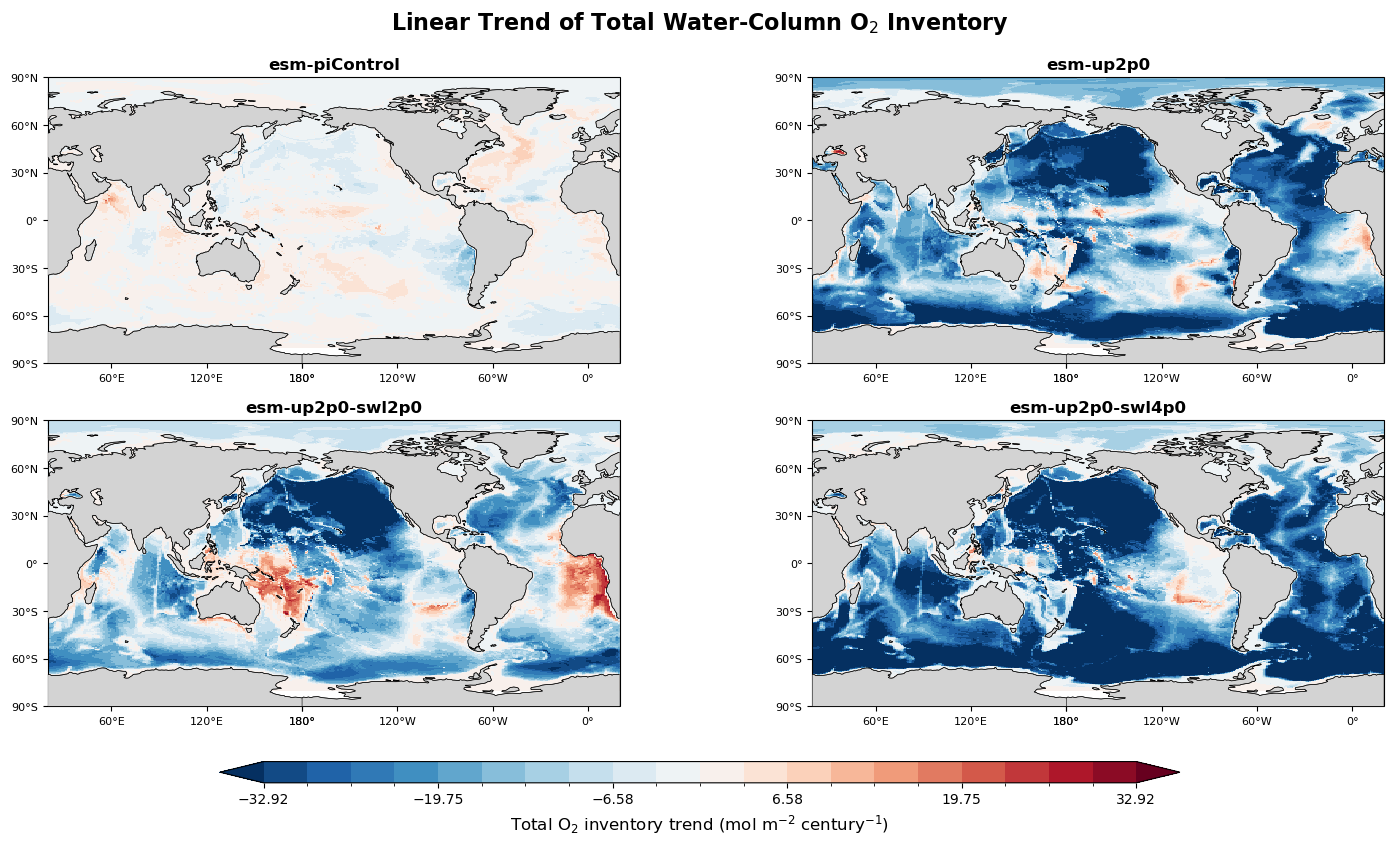

In [6]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import glob
import os
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

# ============================================================
# Settings
# ============================================================

EXP_INFO = {
    "esm-piControl": {
        "path": "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-piControl/latest/o2-inventories",
        "pattern": "o2-inventories_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_*.nc",
    },
    "esm-up2p0": {
        "path": "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/o2-inventories",
        "pattern": "o2-inventories_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",
    },
    "esm-up2p0-swl2p0": {
        "path": "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0-swl2p0/v20251009/o2-inventories",
        "pattern": "o2-inventories_Omon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gr_*.nc",
    },
    "esm-up2p0-swl4p0": {
        "path": "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0-swl4p0/v20251010/o2-inventories",
        "pattern": "o2-inventories_Omon_NorESM2-LM_esm-up2p0-swl4p0_r1i1p1f1_gr_*.nc",
    },
}

VAR_NAME = "o2_inv_total"


# ============================================================
# Function
# ============================================================

def compute_o2_inventory_trend_map(exp_path, pattern, var_name):
    files = sorted(glob.glob(os.path.join(exp_path, pattern)))

    if len(files) == 0:
        raise FileNotFoundError(f"No files found: {os.path.join(exp_path, pattern)}")

    print(f"Found {len(files)} files")
    print(files[0])
    print(files[-1])

    ds = xr.open_mfdataset(
        files,
        combine="by_coords",
        use_cftime=True,
        data_vars="minimal",
        coords="minimal",
        compat="override",
        chunks={"time": 120},
    )

    inv = ds[var_name]

    inv_ann = inv.groupby("time.year").mean("time")

    year = inv_ann["year"]
    x = year - year.mean()

    trend = (
        (inv_ann * x).sum("year", skipna=True)
        / (x ** 2).sum("year", skipna=True)
    ) * 100.0

    trend.name = f"{var_name}_trend"
    trend.attrs["units"] = "mol m-2 century-1"

    trend = trend.assign_coords(
        longitude=ds["longitude"],
        latitude=ds["latitude"],
    )

    trend = trend.compute()

    ds.close()

    return trend


# ============================================================
# Compute trend maps
# ============================================================

trend_dict = {}

for exp, info in EXP_INFO.items():
    print("\n======================================")
    print(exp)
    print("======================================")

    trend_dict[exp] = compute_o2_inventory_trend_map(
        exp_path=info["path"],
        pattern=info["pattern"],
        var_name=VAR_NAME,
    )


# ============================================================
# Plot 2 x 2 panel
# ============================================================

data_crs = ccrs.PlateCarree()
map_crs = ccrs.PlateCarree(central_longitude=200)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 8.5),
    subplot_kw={"projection": map_crs},
)

axes = axes.flatten()

# ------------------------------------------------------------
# common color range: based only on esm-up2p0
# cover about 90% of esm-up2p0 trend magnitudes
# ------------------------------------------------------------

ref_trend = trend_dict["esm-up2p0"]

ref_values = ref_trend.values
ref_values = ref_values[np.isfinite(ref_values)]

vmax = np.nanpercentile(np.abs(ref_values), 90)
vmin = -vmax

levels = np.linspace(vmin, vmax, 21)

cmap = plt.get_cmap("RdBu_r", len(levels) + 1).copy()
cmap.set_bad(alpha=0)

norm = mcolors.BoundaryNorm(
    levels,
    cmap.N,
    extend="both"
)

# ------------------------------------------------------------
# draw maps
# ------------------------------------------------------------

for ax, (exp, trend) in zip(axes, trend_dict.items()):

    pcm = ax.pcolormesh(
        trend["longitude"],
        trend["latitude"],
        trend,
        transform=data_crs,
        cmap=cmap,
        norm=norm,
        shading="auto",
    )

    ax.add_feature(
        cfeature.LAND,
        facecolor="lightgray",
        edgecolor="black",
        linewidth=0.3,
        zorder=10,
    )

    ax.coastlines(
        resolution="110m",
        linewidth=0.5,
        zorder=11,
    )

    ax.set_global()

    ax.set_xticks(np.arange(-180, 181, 60), crs=data_crs)
    ax.set_yticks(np.arange(-90, 91, 30), crs=data_crs)

    ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
    ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())

    ax.tick_params(labelsize=8)

    ax.set_title(
        exp,
        fontsize=12,
        fontweight="bold",
    )

# ------------------------------------------------------------
# layout first, then add colorbar outside
# ------------------------------------------------------------

fig.subplots_adjust(
    left=0.05,
    right=0.97,
    top=0.90,
    bottom=0.16,
    wspace=0.08,
    hspace=0.20,
)

cbar_ax = fig.add_axes([0.20, 0.07, 0.60, 0.025])

cbar = fig.colorbar(
    pcm,
    cax=cbar_ax,
    orientation="horizontal",
    boundaries=levels,
    ticks=levels[::4],
    spacing="proportional",
    extend="both",
)

cbar.set_label(
    "Total O$_2$ inventory trend (mol m$^{-2}$ century$^{-1}$)",
    fontsize=12,
)

fig.suptitle(
    "Linear Trend of Total Water-Column O$_2$ Inventory",
    fontsize=16,
    fontweight="bold",
)

plt.show()


esm-piControl
Found 25 files
First: /nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-piControl/latest/o2-inventories-mesopelagic/o2-inv-200-1000m_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_185101-186012.nc
Last : /nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-piControl/latest/o2-inventories-mesopelagic/o2-inv-200-1000m_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_209101-210012.nc
  [1/25] o2-inv-200-1000m_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_185101-186012.nc
  [2/25] o2-inv-200-1000m_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_186101-187012.nc
  [3/25] o2-inv-200-1000m_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_187101-188012.nc
  [4/25] o2-inv-200-1000m_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_188101-189012.nc
  [5/25] o2-inv-200-1000m_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_189101-190012.nc
  [6/25] o2-inv-200-1000m_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_190101-191012.nc
  [7/25] o2-inv-200-1000m_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_1911

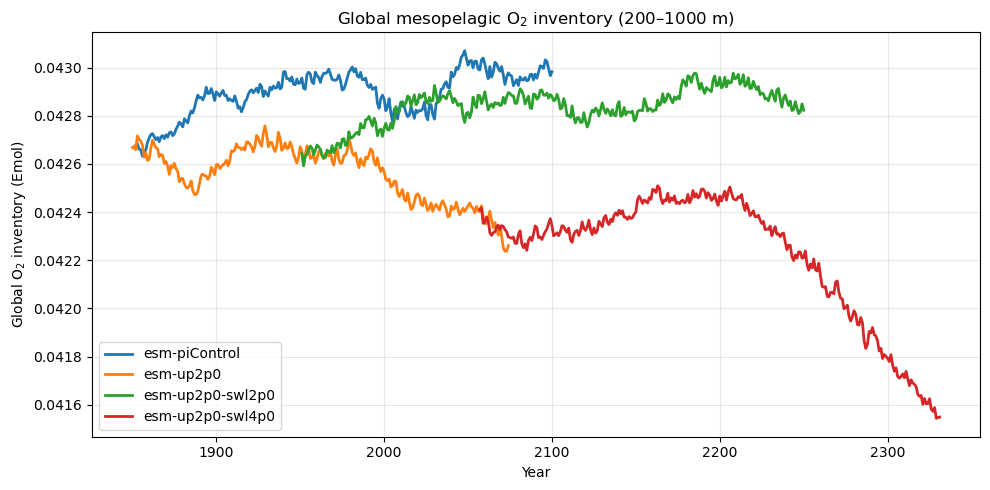

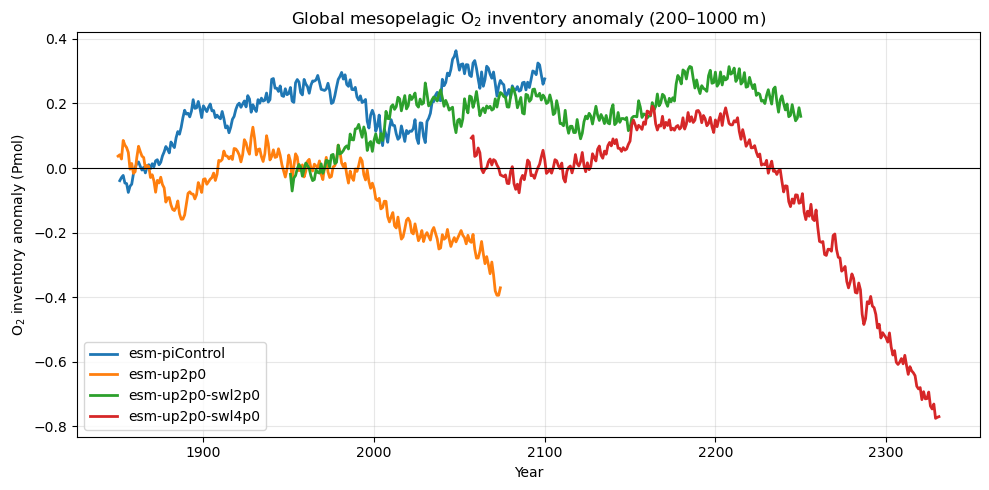

In [7]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

# ============================================================
# Settings
# ============================================================

VAR_NAME = "o2_inv_200_1000m"

AREACELLO_FILE = (
    "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010/"
    "areacello_Ofx_NorESM2-LM_esm-up2p0_r1i1p1f1_gn.nc"
)

EXP_INFO = {
    "esm-piControl": {
        "path": "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-piControl/latest/o2-inventories-mesopelagic",
        "pattern": "o2-inv-200-1000m_Omon_NorESM2-LM_esm-piControl_r1i1p1f1_gr_*.nc",
    },
    
    "esm-up2p0": {
        "path": "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/o2-inventories-mesopelagic",
        "pattern": "o2-inv-200-1000m_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc",

    },
    
    "esm-up2p0-swl2p0": {
        "path": "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0-swl2p0/v20251009/o2-inventories-mesopelagic",
        "pattern": "o2-inv-200-1000m_Omon_NorESM2-LM_esm-up2p0-swl2p0_r1i1p1f1_gr_*.nc",
    },

    "esm-up2p0-swl4p0": {
        "path": "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0-swl4p0/v20251010/o2-inventories-mesopelagic",
        "pattern": "o2-inv-200-1000m_Omon_NorESM2-LM_esm-up2p0-swl4p0_r1i1p1f1_gr_*.nc",
    },
    
}


# ============================================================
# Functions
# ============================================================

def load_area_on_data_grid(areacello_file, data_array):
    """
    Load areacello and align dimension names/order to inventory data.
    """

    ds_area = xr.open_dataset(areacello_file)
    area = ds_area["areacello"]

    # Rename area dims if needed
    rename_dict = {}

    if "j" in data_array.dims and "i" in data_array.dims:
        if "y" in area.dims:
            rename_dict["y"] = "j"
        if "x" in area.dims:
            rename_dict["x"] = "i"

    if "lat" in data_array.dims and "lon" in data_array.dims:
        if "j" in area.dims:
            rename_dict["j"] = "lat"
        if "i" in area.dims:
            rename_dict["i"] = "lon"

    if rename_dict:
        area = area.rename(rename_dict)

    # Keep only horizontal dims used by inventory data
    horiz_dims = [d for d in area.dims if d in data_array.dims]
    area = area.transpose(*horiz_dims)

    return area


def load_global_sum_o2_inventory_fast(exp_path, pattern, var_name, areacello_file):
    files = sorted(glob.glob(os.path.join(exp_path, pattern)))

    if len(files) == 0:
        raise FileNotFoundError(f"No files found:\n{os.path.join(exp_path, pattern)}")

    print(f"Found {len(files)} files")
    print("First:", files[0])
    print("Last :", files[-1])

    out_list = []

    # Open first file only to align area
    with xr.open_dataset(files[0], use_cftime=True) as ds0:
        inv0 = ds0[var_name]
        area = load_area_on_data_grid(areacello_file, inv0).load()

    for i, f in enumerate(files, 1):
        print(f"  [{i}/{len(files)}] {os.path.basename(f)}")

        with xr.open_dataset(f, use_cftime=True) as ds:
            inv = ds[var_name]

            # mol m-2 * m2 = mol
            global_inv_mon = (inv * area).sum(dim=area.dims, skipna=True)

            # compute immediately before closing file
            global_inv_mon = global_inv_mon.load()

            out_list.append(global_inv_mon)

    global_inv_mon_all = xr.concat(out_list, dim="time")
    global_inv_ann = global_inv_mon_all.groupby("time.year").mean("time")
    global_inv_ann.name = var_name + "_global"

    return global_inv_ann


# ============================================================
# Load all experiments
# ============================================================

o2_ann_dict = {}

for exp, info in EXP_INFO.items():

    print("\n======================================")
    print(exp)
    print("======================================")

    o2_ann_dict[exp] = load_global_sum_o2_inventory_fast(
        exp_path=info["path"],
        pattern=info["pattern"],
        var_name=VAR_NAME,
        areacello_file=AREACELLO_FILE,
    )


# ============================================================
# Quick range check
# ============================================================

print("\n======================================")
print("Inventory range")
print("======================================")

for exp, o2_ann in o2_ann_dict.items():
    print(
        f"{exp}: "
        f"min={float(o2_ann.min() / 1e18):.3f} Emol, "
        f"max={float(o2_ann.max() / 1e18):.3f} Emol"
    )


# ============================================================
# Plot 1. Absolute global mesopelagic O2 inventory
# ============================================================

plt.figure(figsize=(10, 5))

for exp, o2_ann in o2_ann_dict.items():

    plt.plot(
        o2_ann["year"],
        o2_ann / 1e18,
        lw=2,
        label=exp,
    )

plt.xlabel("Year")
plt.ylabel("Global O$_2$ inventory (Emol)")
plt.title("Global mesopelagic O$_2$ inventory (200–1000 m)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# Plot 2. Anomaly relative to first 30 years
# ============================================================

plt.figure(figsize=(10, 5))

for exp, o2_ann in o2_ann_dict.items():

    o2_ref = o2_ann.isel(year=slice(0, 30)).mean("year")
    o2_anom = o2_ann - o2_ref

    plt.plot(
        o2_ann["year"],
        o2_anom / 1e15,
        lw=2,
        label=exp,
    )

plt.axhline(0, color="k", lw=0.8)
plt.xlabel("Year")
plt.ylabel("O$_2$ inventory anomaly (Pmol)")
plt.title("Global mesopelagic O$_2$ inventory anomaly (200–1000 m)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()